<a href="https://www.kaggle.com/code/sonawanelalitsunil/netflix-movies-tv-shows-till-2025?scriptVersionId=228613081" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/netflix-movies-and-tv-shows-till-2025/netflix_movies_detailed_up_to_2025.csv
/kaggle/input/netflix-movies-and-tv-shows-till-2025/netflix_tv_shows_detailed_up_to_2025.csv


## Netflix Movies & TV Shows (Till 2025)

## Import dataset

In [2]:
movie = pd.read_csv('/kaggle/input/netflix-movies-and-tv-shows-till-2025/netflix_movies_detailed_up_to_2025.csv')

In [3]:
movie.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,NaN,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000,752600867
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,NaN,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000,839030630
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,NaN,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000,954305868
3,38757,Movie,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",United States of America,2010-11-24,2010,7.600,NaN,"Animation, Family, Adventure",en,"Feisty teenager Rapunzel, who has long and mag...",111.762,11638,7.600,260000000,592461732
4,10191,Movie,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",United States of America,2010-03-18,2010,7.800,NaN,"Fantasy, Adventure, Animation, Family",en,As the son of a Viking leader on the cusp of m...,110.044,13259,7.800,165000000,494879471


In [4]:
movie.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue
15995,1440286,Movie,Festival de Viña del Mar 2025: Ha*Ash,NaN,Ha*ash,Chile,2025-02-24,2025,0.0,NaN,Music,es,NaN,4.931,0,0.0,0,0
15996,1271724,Movie,Man and Woman,Vladimir Kott,"Anna Kotova, Stepan Devonin, Pavel Derevyanko,...",Russia,2025-03-13,2025,0.0,NaN,Drama,ru,Poignant stories about men and women who have ...,4.930,0,0.0,0,0
15997,1426364,Movie,Night of the Dead Sorority Babes,"Angel Nichole Bradford, Steve Hermann","Jessa Flux, Lynn Lowry, Angel Nichole Bradford...",NaN,2025-01-28,2025,1.0,NaN,Horror,en,Two villainous entities initiate gorgeous soro...,4.922,1,1.0,0,0
15998,1411248,Movie,A Dunces Burden,Daniel Kowal,"Riley G, Mitchel Corrado",NaN,2025-03-10,2025,0.0,NaN,NaN,en,A Dunces Burden,4.921,0,0.0,0,0
15999,1405742,Movie,Portal to Hell,Woody Bess,"Trey Holland, Keith David, Richard Kind, Micha...",United States of America,2025-02-22,2025,0.0,NaN,"Comedy, Horror",en,After a debt-collector finds a portal to hell ...,4.921,0,0.0,0,0


In [5]:
movie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16000 non-null  int64  
 1   type          16000 non-null  object 
 2   title         16000 non-null  object 
 3   director      15868 non-null  object 
 4   cast          15796 non-null  object 
 5   country       15534 non-null  object 
 6   date_added    16000 non-null  object 
 7   release_year  16000 non-null  int64  
 8   rating        16000 non-null  float64
 9   duration      0 non-null      float64
 10  genres        15893 non-null  object 
 11  language      16000 non-null  object 
 12  description   15868 non-null  object 
 13  popularity    16000 non-null  float64
 14  vote_count    16000 non-null  int64  
 15  vote_average  16000 non-null  float64
 16  budget        16000 non-null  int64  
 17  revenue       16000 non-null  int64  
dtypes: float64(4), int64(5), o

In [6]:
movie.describe()

,show_id,release_year,rating,duration,popularity,vote_count,vote_average,budget,revenue
count,1.600000e+04,16000.000000,16000.000000,0.0,16000.000000,16000.000000,16000.000000,1.600000e+04,1.600000e+04
mean,5.266582e+05,2017.500000,5.956368,NaN,20.384728,718.656125,5.956368,8.766792e+06,2.446308e+07
std,3.794427e+05,4.609916,1.754741,NaN,68.610033,2080.198316,1.754741,2.912450e+07,1.116977e+08
min,1.890000e+02,2010.000000,0.000000,NaN,3.860000,0.000000,0.000000,0.000000e+00,0.000000e+00
25%,2.257258e+05,2013.750000,5.600000,NaN,7.840750,53.000000,5.600000,0.000000e+00,0.000000e+00
50%,4.468170e+05,2017.500000,6.300000,NaN,10.913500,138.000000,6.300000,0.000000e+00,0.000000e+00
75%,7.739808e+05,2021.250000,6.923000,NaN,17.336500,422.000000,6.923000,2.200000e+06,1.654473e+06
max,1.440471e+06,2025.000000,10.000000,NaN,3876.006000,37119.000000,10.000000,4.600000e+08,2.799439e+09


In [7]:
movie.isnull().sum()

show_id             0
type                0
title               0
director          132
cast              204
country           466
date_added          0
release_year        0
rating              0
duration        16000
genres            107
language            0
description       132
popularity          0
vote_count          0
vote_average        0
budget              0
revenue             0
dtype: int64

In [8]:
movie.duplicated().sum()

0

In [9]:
movie.shape

(16000, 18)

In [10]:
movie.corr

<bound method DataFrame.corr of        show_id   type                                         title  \
0        10192  Movie                           Shrek Forever After   
1        27205  Movie                                     Inception   
2        12444  Movie  Harry Potter and the Deathly Hallows: Part 1   
3        38757  Movie                                       Tangled   
4        10191  Movie                      How to Train Your Dragon   
...        ...    ...                                           ...   
15995  1440286  Movie         Festival de Viña del Mar 2025: Ha*Ash   
15996  1271724  Movie                                 Man and Woman   
15997  1426364  Movie              Night of the Dead Sorority Babes   
15998  1411248  Movie                               A Dunces Burden   
15999  1405742  Movie                                Portal to Hell   

                                    director  \
0                              Mike Mitchell   
1                  

In [11]:
movie.dtypes

show_id           int64
type             object
title            object
director         object
cast             object
country          object
date_added       object
release_year      int64
rating          float64
duration        float64
genres           object
language         object
description      object
popularity      float64
vote_count        int64
vote_average    float64
budget            int64
revenue           int64
dtype: object

In [12]:
movie.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres', 'language',
       'description', 'popularity', 'vote_count', 'vote_average', 'budget',
       'revenue'],
      dtype='object')

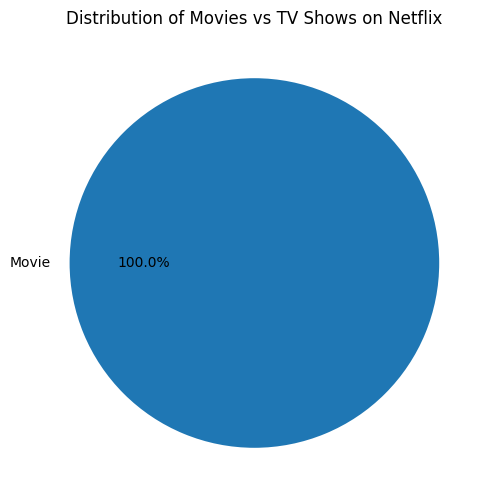

In [13]:
plt.figure(figsize=(8, 6))
movie['type'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#1f77b4', '#ff7f0e'])
plt.title('Distribution of Movies vs TV Shows on Netflix')
plt.ylabel('')
plt.show()

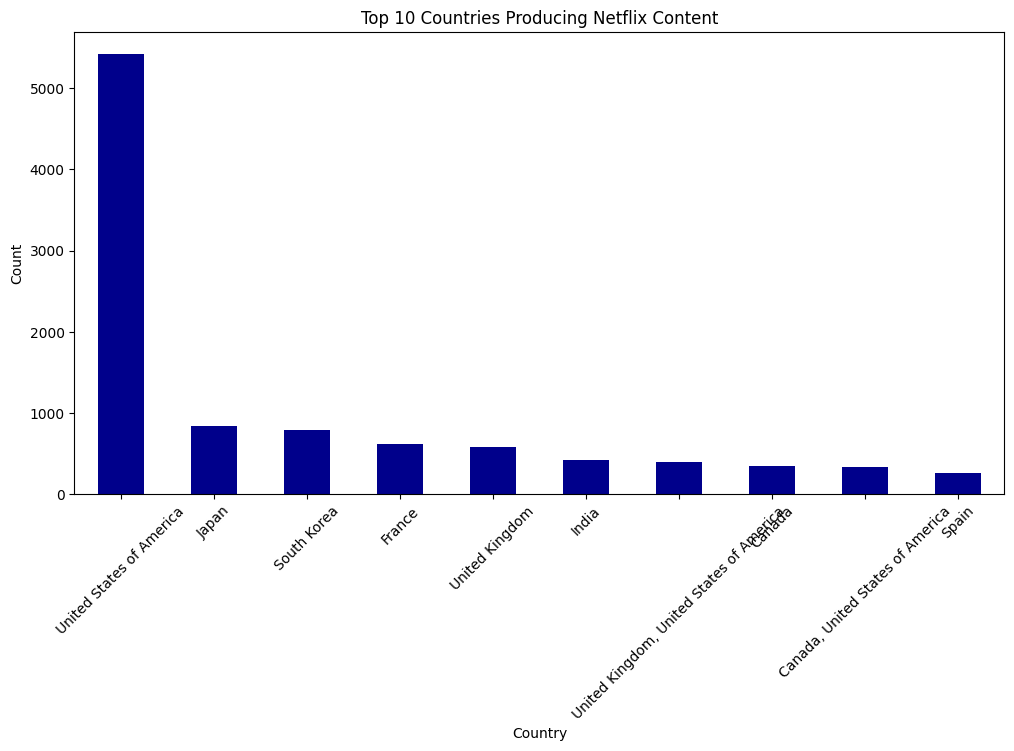

In [14]:
plt.figure(figsize=(12, 6))
movie['country'].value_counts().head(10).plot(kind='bar', color='darkblue')
plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

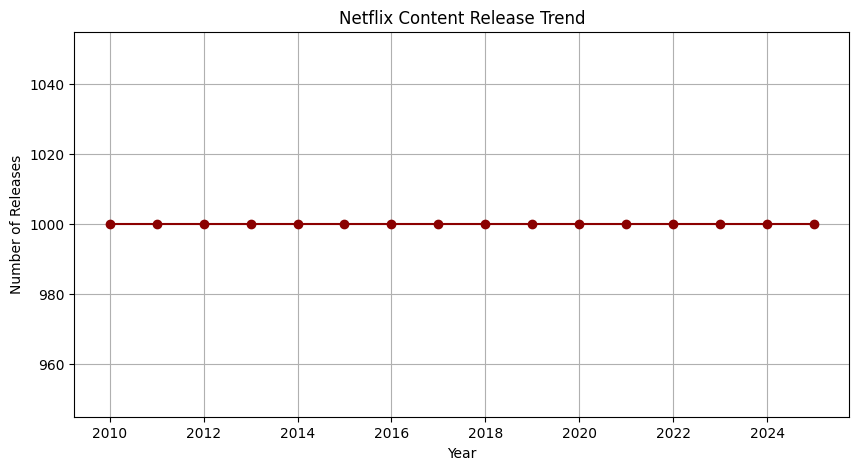

In [15]:
plt.figure(figsize=(10, 5))
movie['release_year'].value_counts().sort_index().plot(kind='line', marker='o', color='darkred')
plt.title('Netflix Content Release Trend')
plt.xlabel('Year')
plt.ylabel('Number of Releases')
plt.grid()
plt.show()


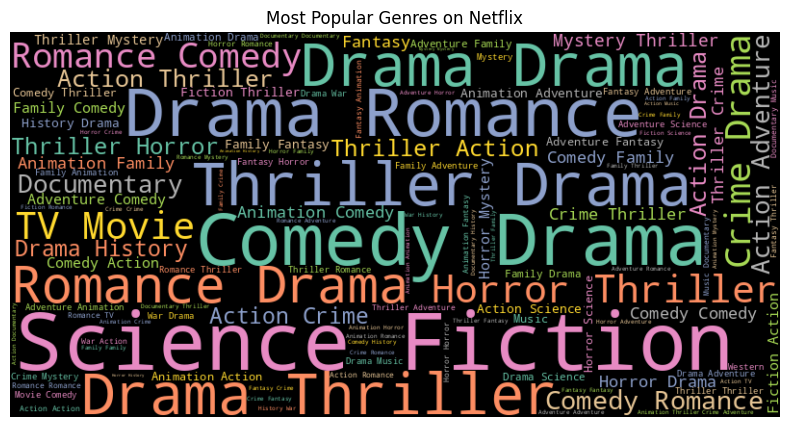

In [16]:
from wordcloud import WordCloud

text = ' '.join(movie['genres'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='black', colormap='Set2').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Popular Genres on Netflix')
plt.show()

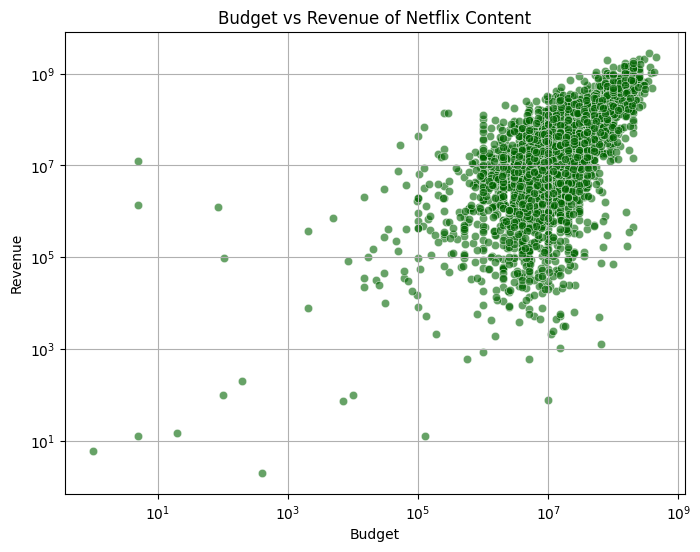

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=movie['budget'], y=movie['revenue'], alpha=0.6, color='darkgreen')
plt.title('Budget vs Revenue of Netflix Content')
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.xscale('log')
plt.yscale('log')
plt.grid(True)
plt.show()


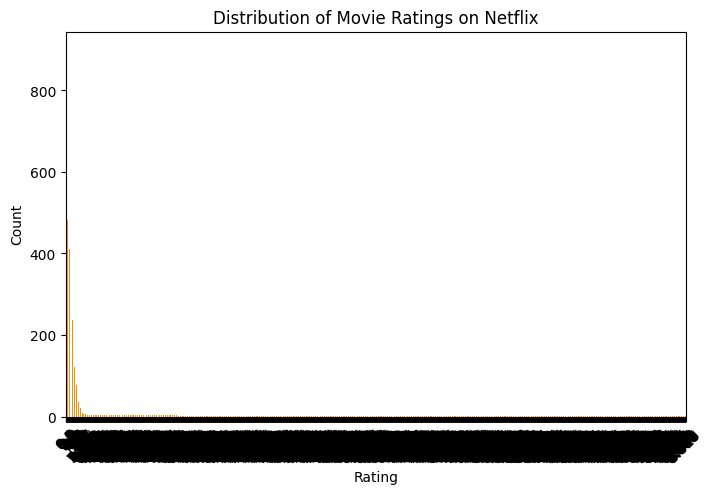

In [18]:
plt.figure(figsize=(8, 5))
movie['rating'].value_counts().plot(kind='bar', color='darkorange')
plt.title('Distribution of Movie Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


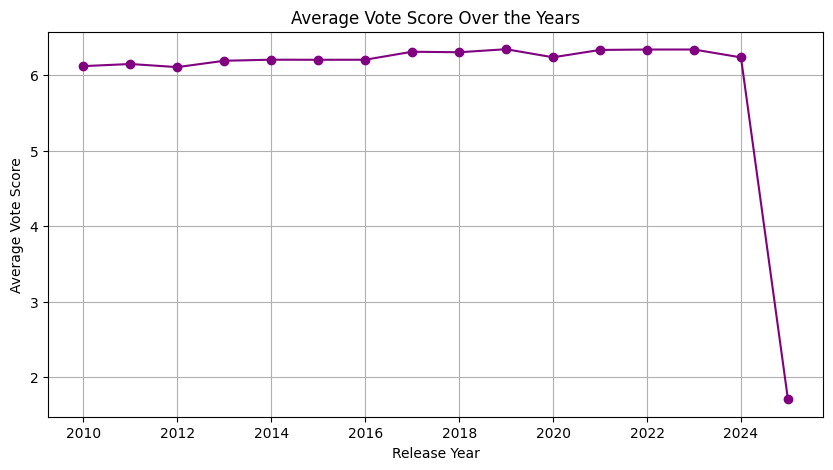

In [19]:
plt.figure(figsize=(10, 5))
movie.groupby('release_year')['vote_average'].mean().plot(kind='line', marker='o', color='purple')
plt.title('Average Vote Score Over the Years')
plt.xlabel('Release Year')
plt.ylabel('Average Vote Score')
plt.grid()
plt.show()


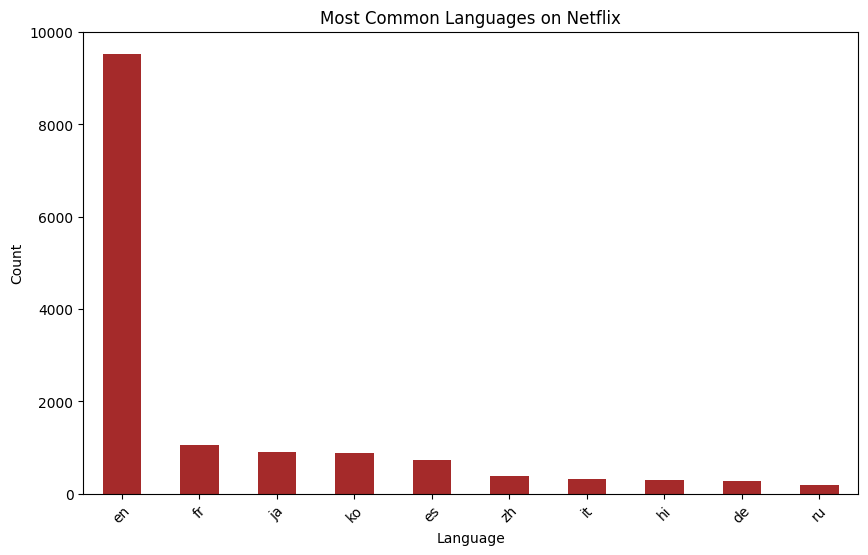

In [20]:
plt.figure(figsize=(10, 6))
movie['language'].value_counts().head(10).plot(kind='bar', color='brown')
plt.title('Most Common Languages on Netflix')
plt.xlabel('Language')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


## Thanks..pls upvote!!